In [1]:
import os, time, random
import torch
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

torch.manual_seed(0);np.random.seed(0);random.seed(0)

from diffusion_linking.data import generate_circles
from diffusion_linking.diffusion import VariationalDiffusion
from diffusion_linking.clustering import Clusterer, Cluster
from diffusion_linking.schedule import LinearSchedule

device = 'cpu' if torch.cuda.device_count()==0 else 'cuda'

In [2]:
schedule = LinearSchedule()
model = VariationalDiffusion(dim=2, depth=12, schedule=schedule).to(device)

checkpoint_path = "circles_scheduled.pt"
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint['model'])
loss_history = checkpoint['loss_history']
model = model.to(device)

Dataset to cluster - lots of overlap.

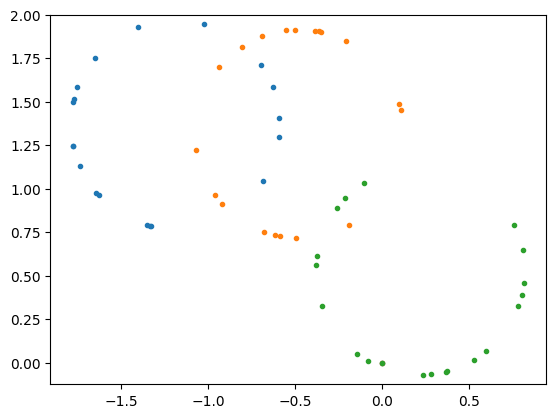

In [3]:
torch.manual_seed(2)
circles_valid, masks_valid = generate_circles(3, min_points=19, max_points=20, min_radius=0.6, max_radius=0.6)
for cc in circles_valid:
    plt.plot(cc[:, 0], cc[:, 1], 'o', markersize=3)
plt.axis('equal')
plt.show()

cluster_data = []
for c, m in zip(circles_valid, masks_valid):
    for ci, mi in zip(c, m):
        if mi:
            cluster_data.append(ci.unsqueeze(0))
            
random.shuffle(cluster_data)

Define clustering algorithm - I tried to structure this implementation to be close to the original algorithm.

In [4]:

class SMCClusterer:
    def __init__(self, data, score_fn, max_particles, alpha):
        self.data = data
        self.score_fn = score_fn
        self.max_particles = max_particles
        self.alpha = alpha
        self.score_cache = {}
        self.particles = []
        self.weights = []
        self.n_obs = 0

    def compute_scores(self, clusters, force_recompute=False):
        """
        For a list of clusters, compute the score for each cluster.

        We use a cache to avoid recomputing scores for clusters that have already been computed.

        The score function is assumed to take a batch of data and a batch of masks,
        and return a batch of scores. The shape of the data is (batch_size, max_cluster_size, dim),
        the shape of the mask is (batch_size, max_cluster_size), and the shape of the scores is (batch_size,).
        """
        # remove the score from the cache if we're forcing a recompute
        if force_recompute:
            [self.score_cache.pop(cluster.hash, None) for cluster in clusters]

        # prepare the data and masks
        max_size = max([c.size for c in clusters])
        data, masks, hashes = [], [], []
        for cluster in clusters:
            if cluster.hash in self.score_cache:
                continue

            hashes.append(cluster.hash)

            # prepare masks
            mask = torch.zeros(max_size, dtype=torch.bool)
            mask[: cluster.size] = True
            masks.append(mask)

            # append nans onto data to make it the same size
            padding = torch.zeros(max_size - cluster.size, cluster.data.shape[1]).fill_(float('nan'))
            data.append(torch.cat([cluster.data, padding], dim=0))

        # compute a batch of scores, if any to compute
        if len(data) > 0:
            scores = self.score_fn(torch.stack(data), torch.stack(masks))

            # hash the scores so we don't need to recompute later
            for score, hash_ in zip(scores, hashes):
                self.score_cache[hash_] = score

        # retrieve the scores from the cache
        for cluster in clusters:
            cluster.score = self.score_cache[cluster.hash]
            
    def prior(self, cluster_size):
        # Prior probability of a clustering, based on cluster size and hyperparameter alpha
        return np.log(cluster_size/(self.n_obs + self.alpha)) if cluster_size>1 else np.log(self.alpha/(self.n_obs + self.alpha))
        
    def update_particle(self, new_obs, particle, weight):
        # Compute possible descendants (and their weights) of a particle given new observation
        possible_assignments = [new_obs] + [ old_cluster.merge(new_obs) for old_cluster in particle ]
        self.compute_scores(possible_assignments)
        putative_weights = [weight + self.prior(1) + self.score_cache[new_obs.hash]]
        putative_weights += [weight + self.prior(new_cluster.size) - self.prior(old_cluster.size) + self.score_cache[new_cluster.hash] - self.score_cache[old_cluster.hash] for new_cluster, old_cluster in zip(possible_assignments[1:], particle)]
        
        putative_particles = [particle+[new_obs]] + [particle[:j]+particle[(j+1):]+[new_cluster] for j, new_cluster in enumerate(possible_assignments[1:])]
        return putative_particles, putative_weights
    
    def resample(self, particles, weights):
        # Resample particle set
        resample_idx = np.random.choice([i for i in range(len(particles))], self.max_particles, replace=True, p=np.exp(weights)/np.sum(np.exp(weights)))
        unique_idx, counts = np.unique(resample_idx, return_counts=True)
        return [particles[i] for i in unique_idx], [np.log(count/self.max_particles) for count in counts]
    
    def update_step(self, new_obs):
        # Update particle set given new observation
        self.n_obs += 1
        singleton = Cluster(new_obs)
        putative_particles = []
        putative_weights = []
        for particle, weight in zip(self.particles, self.weights):
            p, w = self.update_particle(singleton, particle, weight)
            putative_particles += p
            putative_weights += w
        
        if len(putative_particles) > self.max_particles:
            self.particles, self.weights = self.resample(putative_particles, putative_weights)
        else:
            self.particles, self.weights = putative_particles, putative_weights


    def cluster(self, plots=0):
        # Cluster the dataset in self.data
        self.n_obs += 1
        self.particles = [[Cluster(self.data[0])]]
        self.compute_scores(self.particles[0])
        self.weights = [0]
        for obs in (pbar := tqdm(self.data[1:])):
            self.update_step(obs)
            pbar.set_postfix({"Particles":"%s "%(len(self.particles))})

            if plots and self.n_obs%5==0:
                self.plot_particles(n_plots=plots)
            
        print()

    def summary(self):
        # Print out summary of particle set
        for i, (clusters, weight) in enumerate(sorted(zip(clusterer.particles, clusterer.weights), key=lambda c: c[1], reverse=True)):
            weight = np.exp(weight)/np.sum(np.exp(self.weights))
            clusters = sorted(clusters, key=lambda c: c.size, reverse=True)
            print(f"Particle {i}, weight {weight:.2g}, {len(clusters)} clusters, {sum([c.size for c in clusters])} points, {[c.size for c in clusters]}")           
                        
    def plot_particles(self, n_plots=5, fig_scale=3):
        # Plot particles with highest weights
        n_plots = min(n_plots, len(self.particles))
        ncols = min(5, n_plots)
        nrows = 1 + (n_plots-1)//ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_scale*ncols,fig_scale*nrows))
        for i, (clusters, weight ) in enumerate(sorted(zip(clusterer.particles, clusterer.weights), key=lambda c: c[1], reverse=True)[:n_plots]):
            subfig = axes[int(i//ncols), i%ncols] if nrows>1 else axes[i] if n_plots>1 else axes
            weight = np.exp(weight)/np.sum(np.exp(self.weights))
            clusters = sorted(clusters, key=lambda c: c.size, reverse=True)

            if self.n_obs<len(self.data):
                unobserved_pts = np.array(self.data[self.n_obs:]).squeeze(axis=1)
                subfig.plot(unobserved_pts[:,0], unobserved_pts[:,1], 'x', color='black', alpha=0.25, markersize=2)
                
            for c in clusters:
                if c.size > 1:
                    subfig.plot(c.data[:, 0].cpu().numpy(), c.data[:, 1].cpu().numpy(), 'o', markersize=3)
                else:
                    subfig.plot(c.data[:, 0].cpu().numpy(), c.data[:, 1].cpu().numpy(), 'ks', markersize=3, alpha=0.75)
            subfig.set_title(f'Particle {i+1}/{len(self.particles)}, weight {weight:.2g}')
            subfig.set_aspect('equal')
            subfig.set_xticks([])
            subfig.set_yticks([])

        for i in range(n_plots,nrows*ncols):
            subfig = axes[int(i//ncols), i%ncols] if nrows>1 else axes[i] if n_plots>1 else axes
            subfig.set_xticks([])
            subfig.set_yticks([])          

        fig.tight_layout()
        plt.show()


Cluster the test dataset, plot clusterings with greatest weights.

/home/trojanc1/luna/Clustering/Diffusion-Linking-main/src/diffusion_linking/diffusion.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(i * dt)
/home/trojanc1/luna/Clustering/Diffusion-Linking-main/src/diffusion_linking/diffusion.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(i * dt)
  5%|█▌                            | 3/56 [00:15<01:41,  1.91s/it, Particles=52]

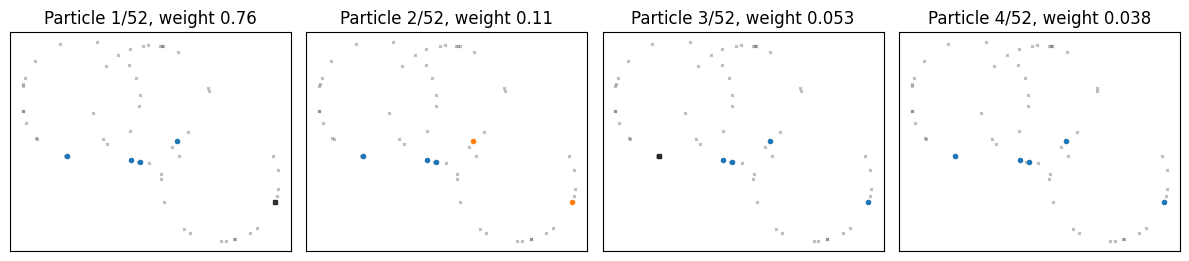

 14%|████▎                         | 8/56 [01:51<18:43, 23.41s/it, Particles=32]

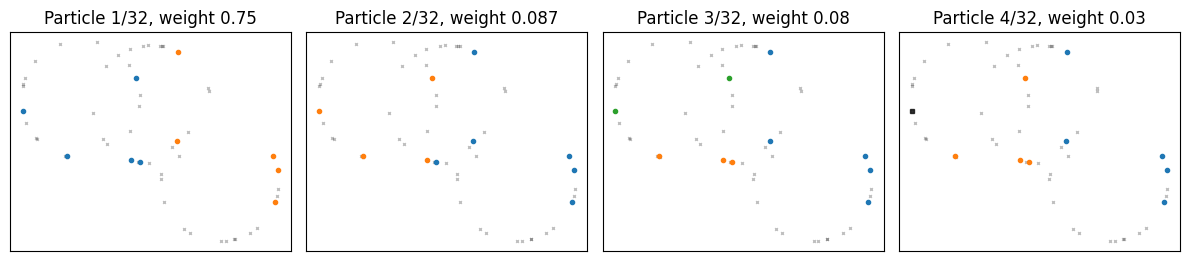

 23%|██████▉                       | 13/56 [02:56<08:43, 12.17s/it, Particles=2]

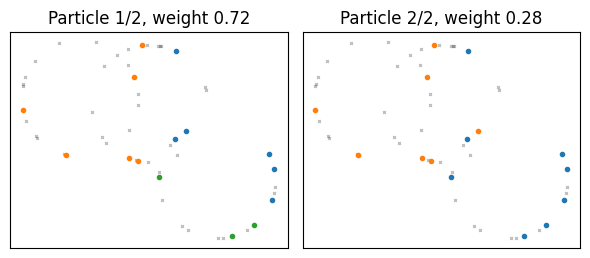

 30%|████████▊                    | 17/56 [03:16<05:53,  9.07s/it, Particles=27]

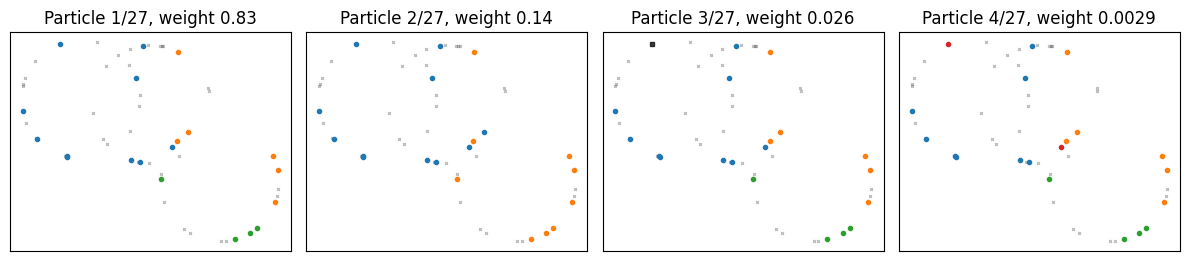

 41%|████████████▎                 | 23/56 [03:46<02:29,  4.53s/it, Particles=1]

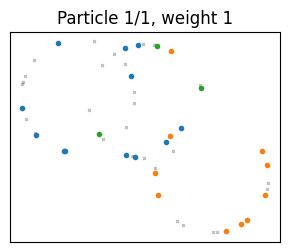

 50%|██████████████▌              | 28/56 [04:13<03:16,  7.02s/it, Particles=36]

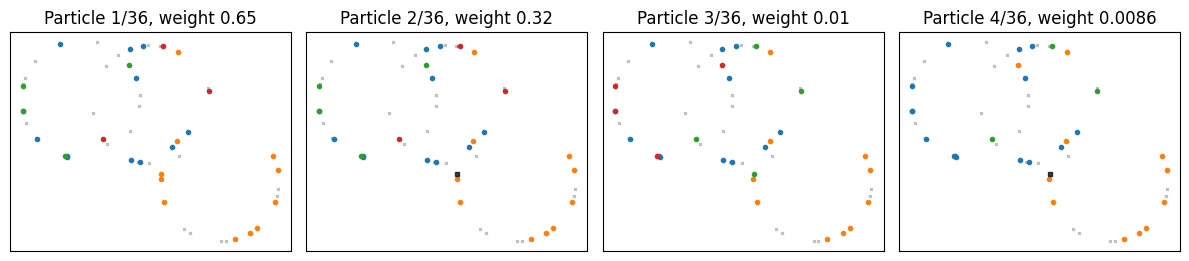

 59%|█████████████████            | 33/56 [04:58<04:16, 11.13s/it, Particles=24]

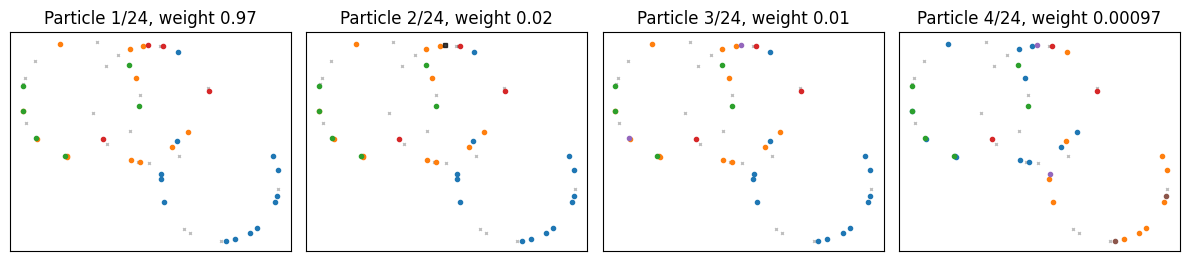

 68%|███████████████████▋         | 38/56 [05:38<02:55,  9.73s/it, Particles=47]

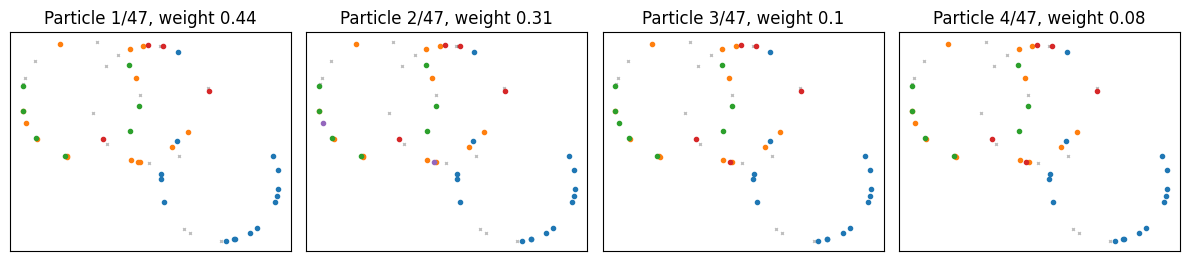

 77%|███████████████████████       | 43/56 [06:10<01:44,  8.03s/it, Particles=5]

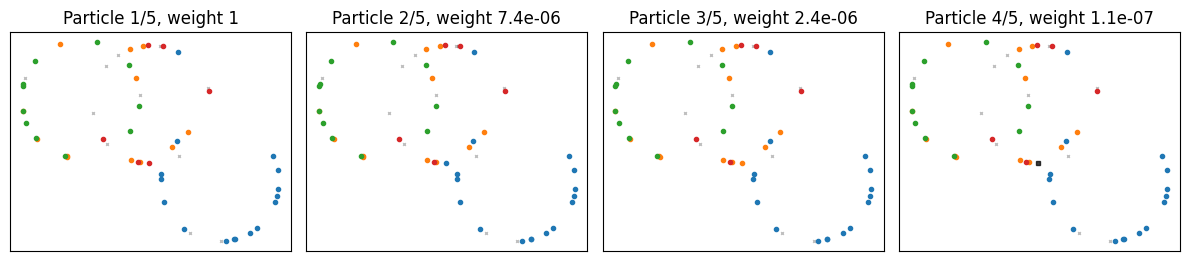

 86%|█████████████████████████▋    | 48/56 [06:43<00:45,  5.63s/it, Particles=1]

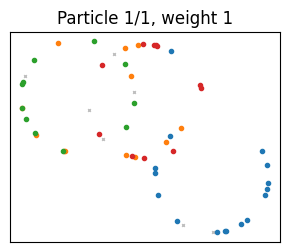

 95%|███████████████████████████▍ | 53/56 [07:03<00:14,  4.92s/it, Particles=26]

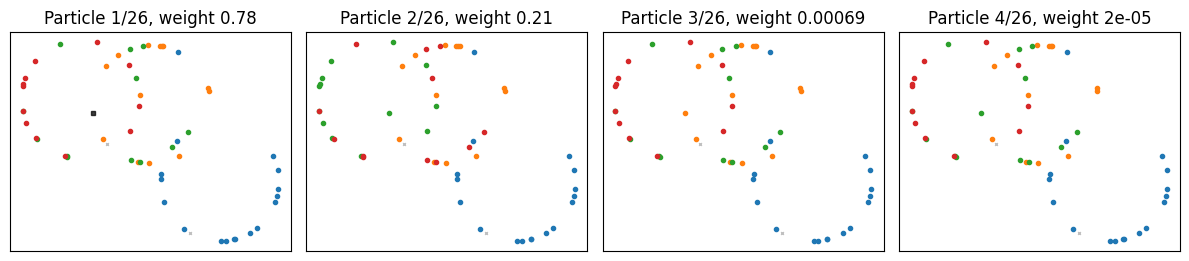

100%|█████████████████████████████| 56/56 [07:11<00:00,  7.71s/it, Particles=16]

In [5]:
num_time_steps = 40
def score_func(data, masks):
    scores, _ = model.log_prob_ode(data.to(device), masks.to(device), num_time_steps=num_time_steps)
    return scores
    
clusterer = SMCClusterer(data=cluster_data, score_fn=score_func, max_particles=100, alpha=0.5)
clusterer.cluster(plots=4)

In [6]:
clusterer.summary()

Particle 0, weight 0.72, 5 clusters, 57 points, [17, 13, 12, 12, 3]
Particle 1, weight 0.27, 4 clusters, 57 points, [17, 15, 13, 12]
Particle 2, weight 0.0079, 4 clusters, 57 points, [17, 15, 13, 12]
Particle 3, weight 2e-06, 6 clusters, 57 points, [17, 13, 12, 12, 2, 1]
Particle 4, weight 1e-06, 5 clusters, 57 points, [17, 14, 13, 12, 1]
Particle 5, weight 5.8e-07, 5 clusters, 57 points, [17, 13, 13, 12, 2]
Particle 6, weight 3.1e-08, 5 clusters, 57 points, [17, 14, 13, 12, 1]
Particle 7, weight 8.9e-09, 4 clusters, 57 points, [17, 14, 13, 13]
Particle 8, weight 1.8e-09, 5 clusters, 57 points, [17, 14, 12, 12, 2]
Particle 9, weight 9.7e-10, 4 clusters, 57 points, [17, 14, 14, 12]
Particle 10, weight 5.4e-11, 5 clusters, 57 points, [17, 13, 13, 12, 2]
Particle 11, weight 2.8e-11, 4 clusters, 57 points, [17, 14, 14, 12]
Particle 12, weight 2.8e-11, 4 clusters, 57 points, [17, 14, 13, 13]
Particle 13, weight 2.5e-13, 5 clusters, 57 points, [18, 13, 12, 12, 2]
Particle 14, weight 1.3e-13,

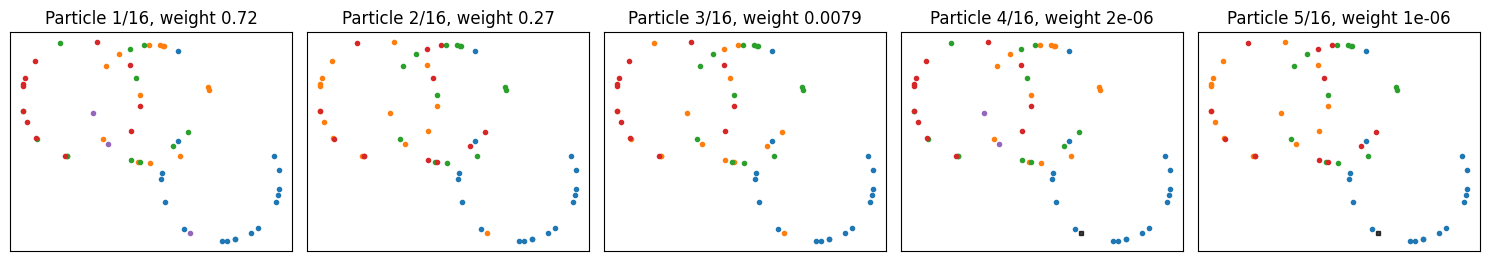

In [7]:
clusterer.plot_particles()

Compare to previous clusterer.

iteration 0, linking score: 9.3500
iteration 0, 56 clusters, 57 points, [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 1, linking score: 7.5659
iteration 1, 55 clusters, 57 points, [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 2, linking score: 11.4017
iteration 2, 54 clusters, 57 points, [3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 3, linking score: 9.1415
iteration 3, 53 clusters, 57 points, [3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 4, linking score: 10.3857
iteration 4, 52 c

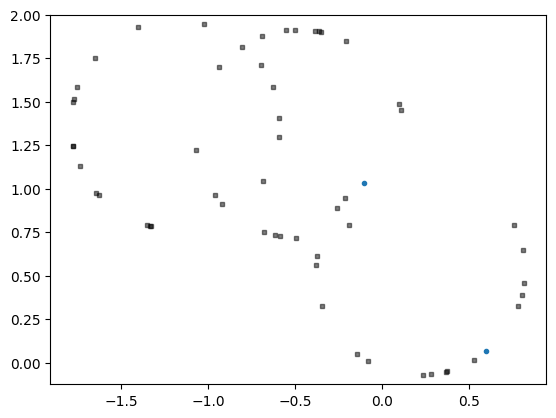

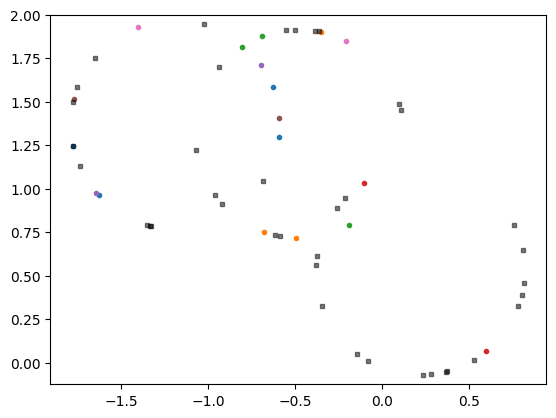

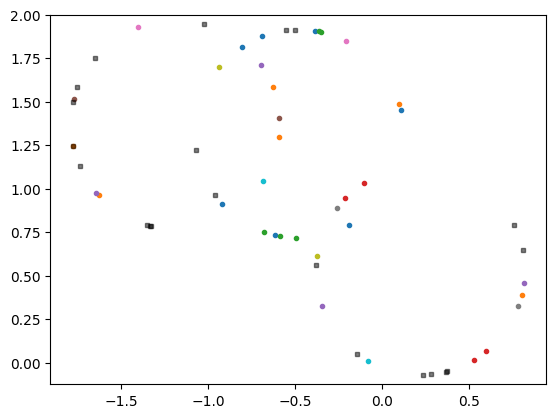

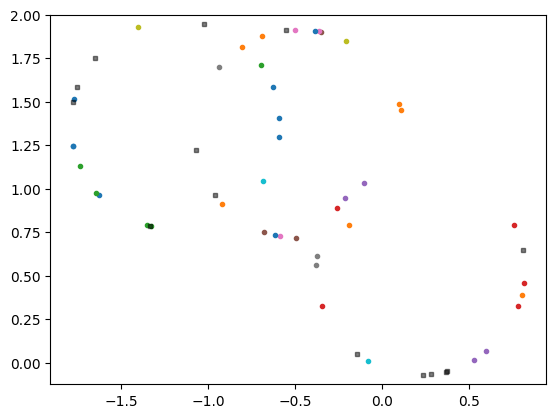

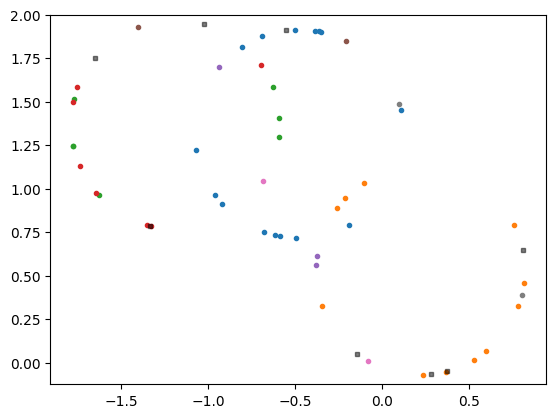

In [8]:
def plot_callback(clusters, iteration):
    # sort clusters by size
    clusters = sorted(clusters, key=lambda c: c.size, reverse=True)
    if iteration % 10 == 0:
        plt.figure()
        for c in clusters:
            if c.size > 1:
                plt.plot(c.data[:, 0].cpu().numpy(), c.data[:, 1].cpu().numpy(), 'o', markersize=3)
            else:
                plt.plot(c.data[:, 0].cpu().numpy(), c.data[:, 1].cpu().numpy(), 'ks', markersize=3, alpha=0.5)
        plt.axis('equal')

    print(
        f"iteration {iteration}, {len(clusters)} clusters, {sum([c.size for c in clusters])} points, {[c.size for c in clusters]}")

clusterer2 = Clusterer(data=cluster_data, score_fn=score_func, cluster_batch_size=16, link_threshold=0)
clusterer2.cluster(max_iter=100, verbose=True, callback=plot_callback)

iteration 0, 9 clusters, 57 points, [15, 15, 10, 7, 3, 2, 2, 2, 1]


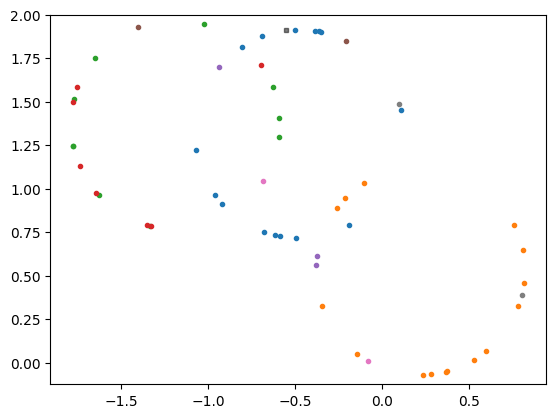

In [9]:
plot_callback(clusterer2.clusters, 0)